In [ ]:
import pandas as pd
import glob
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# อ่านไฟล์ **CSV**

In [ ]:
##df = pd.read_csv('/content/drive/MyDrive/EDA_ScopusData_Midterm/data/ComputerVisionANDPatternRecognition.csv', encoding='utf-8')

folder_path = '/content/drive/MyDrive/EDA_ScopusData_Midterm/data/'
all_files = glob.glob(os.path.join(folder_path, "*.csv")) #หาไฟล์ที่ลงท้ายด้วย.csv

#ลิสต์สำหรับเก็บดาต้าเฟรมของแต่ละไฟล์
df_list = []

for file in all_files:
  temp_df = pd.read_csv(file, encoding='utf-8')
  #ดึงชื่อไฟล์ออกและตัด.csv แล้วสร้างคอลัมน์ subject
  subject_name = os.path.basename(file).replace('.csv', '')
  temp_df['Subject'] = subject_name

  #เอาดาต้าเฟรมไปเก็บไว้ในลิสต์
  df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
print(f"จำนวนข้อมูลทั้งหมด: {df.shape[0]} แถว, {df.shape[1]} คอลัมน์")
display(df.head())

จำนวนข้อมูลทั้งหมด: 5600 แถว, 23 คอลัมน์


,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,Link,Abstract,Author Keywords,Index Keywords,Document Type,Publication Stage,Open Access,Source,EID,Subject
0,Xia X.; Yuruk N.; Wang Y.; Zhai X.,"Xia, Xin (58544876200); Yuruk, Nejla (22959323...",58544876200; 22959323200; 59936586800; 5719268...,Using Learning Progressions to Guide AI Feedba...,2027,Lecture Notes in Computer Science,16585 LNAI,NaN,NaN,195.0,...,https://www.scopus.com/pages/publications/1050...,Generative artificial intelligence (AI) offers...,Feedback; Generative Artificial Intelligence (...,Artificial intelligence; Grading; Learning sys...,Conference paper,Final,NaN,Scopus,2-s2.0-105044000008,Artificial_Intelligence
1,Leite R.; Araújo R.E.,"Leite, Renato (60707898100); Araújo, Rui Estev...",60707898100; 23395865700,Machine Learning on Small Datasets Under Resou...,2027,IFIP Advances in Information and Communication...,790 IFIPAICT,NaN,NaN,71.0,...,https://www.scopus.com/pages/publications/1050...,Artificial Intelligence AI is increasingly pre...,Artificial Intelligence; Embedded Systems; Mac...,Computational efficiency; Deep learning; Embed...,Conference paper,Final,NaN,Scopus,2-s2.0-105042784786,Artificial_Intelligence
2,Hosseinhashemi S.; Liu Q.; Eisa A.; Saifoori S...,"Hosseinhashemi, Somayeh (58629984100); Liu, Qi...",58629984100; 60751131200; 60571652000; 5719771...,Physics-Inspired hybrid AI framework for mecha...,2027,Chemical Engineering Science,338,NaN,124680,NaN,...,https://www.scopus.com/pages/publications/1050...,Modern chemical engineering requires robust ph...,Deep learning networks; Graph attention networ...,Deep neural networks; Engineering education; G...,Article,Final,All Open Access; Hybrid Gold Open Access,Scopus,2-s2.0-105045341986,Artificial_Intelligence
3,Khalid O.; Gamazo-Real J.-C.; Roibás-Millán E.,"Khalid, Omer (60744895700); Gamazo-Real, Jose-...",60744895700; 36503715200; 56808339300,Run-Time Assurance for Onboard COTS-Based AI i...,2027,Lecture Notes in Computer Science,16767 LNCS,NaN,NaN,445.0,...,https://www.scopus.com/pages/publications/1050...,Safety-critical systems are increasingly apply...,Artificial Intelligence; Commercial Off-The-Sh...,Commercial off-the-shelf; Communication satell...,Conference paper,Final,NaN,Scopus,2-s2.0-105044837225,Artificial_Intelligence
4,Shen A.; Yuan M.; Huang Q.; Feng B.; Du J.; Ma...,"Shen, Ao (58769364200); Yuan, Mingzhi (5744468...",58769364200; 57444680700; 59423106600; 5799585...,Functional guidance for whole-protein virtual ...,2027,Information Fusion,138,NaN,104709,NaN,...,https://www.scopus.com/pages/publications/1050...,Virtual screening (VS) for protein targets lac...,AI for science; Contrastive learning; Drug vir...,Artificial intelligence; Biochemistry; Contras...,Article,Final,NaN,Scopus,2-s2.0-105047813094,Artificial_Intelligence


# การกรองซ้ำ

In [ ]:
# เก็บเฉพาะบทความที่ไม่ปรากฏซ้ำใน Subject อื่น (เช็คจากชื่อเรื่อง)
df = df.drop_duplicates(subset=['Title'], keep=False)

print(f"จำนวนข้อมูลหลังลบรายการซ้ำ: {df.shape[0]} แถว")

จำนวนข้อมูลหลังลบรายการซ้ำ: 5036 แถว


# หา Missing **Value**

In [ ]:
#หา Missing Value ในแต่ละคอลัมน์
print("จำนวน Missing Value ในแต่ละคอลัมน์:")
missing_count = df.isnull().sum()
print(missing_count)

print("-" * 30)

#คำนนวณเป็นเปอร์เว็นให้เห็นภาพแจ่มแจ้ง
print("ร้อยละ (%) ของ Missing Value ในแต่ละคอลัมน์:")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.round(2))

print("-" * 30)

#แสดงเฉพาะคอลัมน์ที่มี Missing Value
missing_only = missing_percent[missing_percent > 0]
if not missing_only.empty:
    print("คอลัมน์ที่พบ Missing Value (เรียงจากมากไปน้อย):")
    print(missing_only.sort_values(ascending=False).round(2))
else:
    print("ไม่พบ Missing Value ในชุดข้อมูลนี้")

จำนวน Missing Value ในแต่ละคอลัมน์:
Authors                45
Author full names      45
Author(s) ID           45
Title                   0
Year                    0
Source title            0
Volume                581
Issue                3637
Art. No.             2533
Page start           2697
Page end             2700
Cited by                0
DOI                    66
Link                    0
Abstract                0
Author Keywords       336
Index Keywords        340
Document Type           0
Publication Stage       0
Open Access          3325
Source                  0
EID                     0
Subject                 0
dtype: int64
------------------------------
ร้อยละ (%) ของ Missing Value ในแต่ละคอลัมน์:
Authors               0.89
Author full names     0.89
Author(s) ID          0.89
Title                 0.00
Year                  0.00
Source title          0.00
Volume               11.54
Issue                72.22
Art. No.             50.30
Page start           53.55
Page en

In [ ]:
df.columns

Index(['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year',
       'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end',
       'Cited by', 'DOI', 'Link', 'Abstract', 'Author Keywords',
       'Index Keywords', 'Document Type', 'Publication Stage', 'Open Access',
       'Source', 'EID', 'Subject'],
      dtype='object')

# จัดการ Missing **Value**

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# ==========================================
# 1. โค้ดส่วนต้น (ใช้ของเดิมของคุณได้เลย)
# ==========================================
columns_to_drop = [
    'Volume', 'Issue', 'Art. No.', 'Page start',
    'Page end', 'Open Access', 'EID', 'Link', 'Source'
]
df_clean = df.drop(columns=columns_to_drop)

text_fill_cols = ['Author Keywords', 'Index Keywords', 'Authors', 'Author full names', 'Author(s) ID', 'DOI']
for col in text_fill_cols:
    df_clean[col] = df_clean[col].fillna('')

# ==========================================
# 2. โค้ดส่วนคลีนข้อความ (นำของใหม่มาวางทับตรงนี้)
# ==========================================
stop_words = set(stopwords.words('english'))
custom_noise = [
    'copyright', 'license', 'springer', 'nature', 'switzerland',
    'authors', 'exclusive', 'pte', 'ltd', 'rights', 'reserved',
    'ag', 'publishing', 'singapore', 'llc', 'international'
]
stop_words.update(custom_noise)

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'copyright.*', '', text) # ตัดประโยคลิขสิทธิ์ทิ้ง
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

print("กำลังทำความสะอาดข้อมูล Title และ Abstract...")
df_clean['Clean_Title'] = df_clean['Title'].apply(clean_text)
df_clean['Clean_Abstract'] = df_clean['Abstract'].apply(clean_text)
df_clean['Combined_Text'] = df_clean['Clean_Title'] + " " + df_clean['Clean_Abstract']

print("กระบวนการเสร็จสิ้น ชุดข้อมูลพร้อมสำหรับการทำ Vectorization")
display(df_clean[['Subject', 'Combined_Text']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


กำลังทำความสะอาดข้อมูล Title และ Abstract...
กระบวนการเสร็จสิ้น ชุดข้อมูลพร้อมสำหรับการทำ Vectorization


,Subject,Combined_Text
0,Artificial_Intelligence,using learning progressions guide ai feedback ...
1,Artificial_Intelligence,machine learning small datasets resource const...
2,Artificial_Intelligence,physicsinspired hybrid ai framework mechanisti...
3,Artificial_Intelligence,runtime assurance onboard cotsbased ai safetyc...
4,Artificial_Intelligence,functional guidance wholeprotein virtual scree...


# สร้าง Word Cloud เพื่อดู Keyword ยอดฮิตแยกตาม 10 สาขาวิชา (Subject)

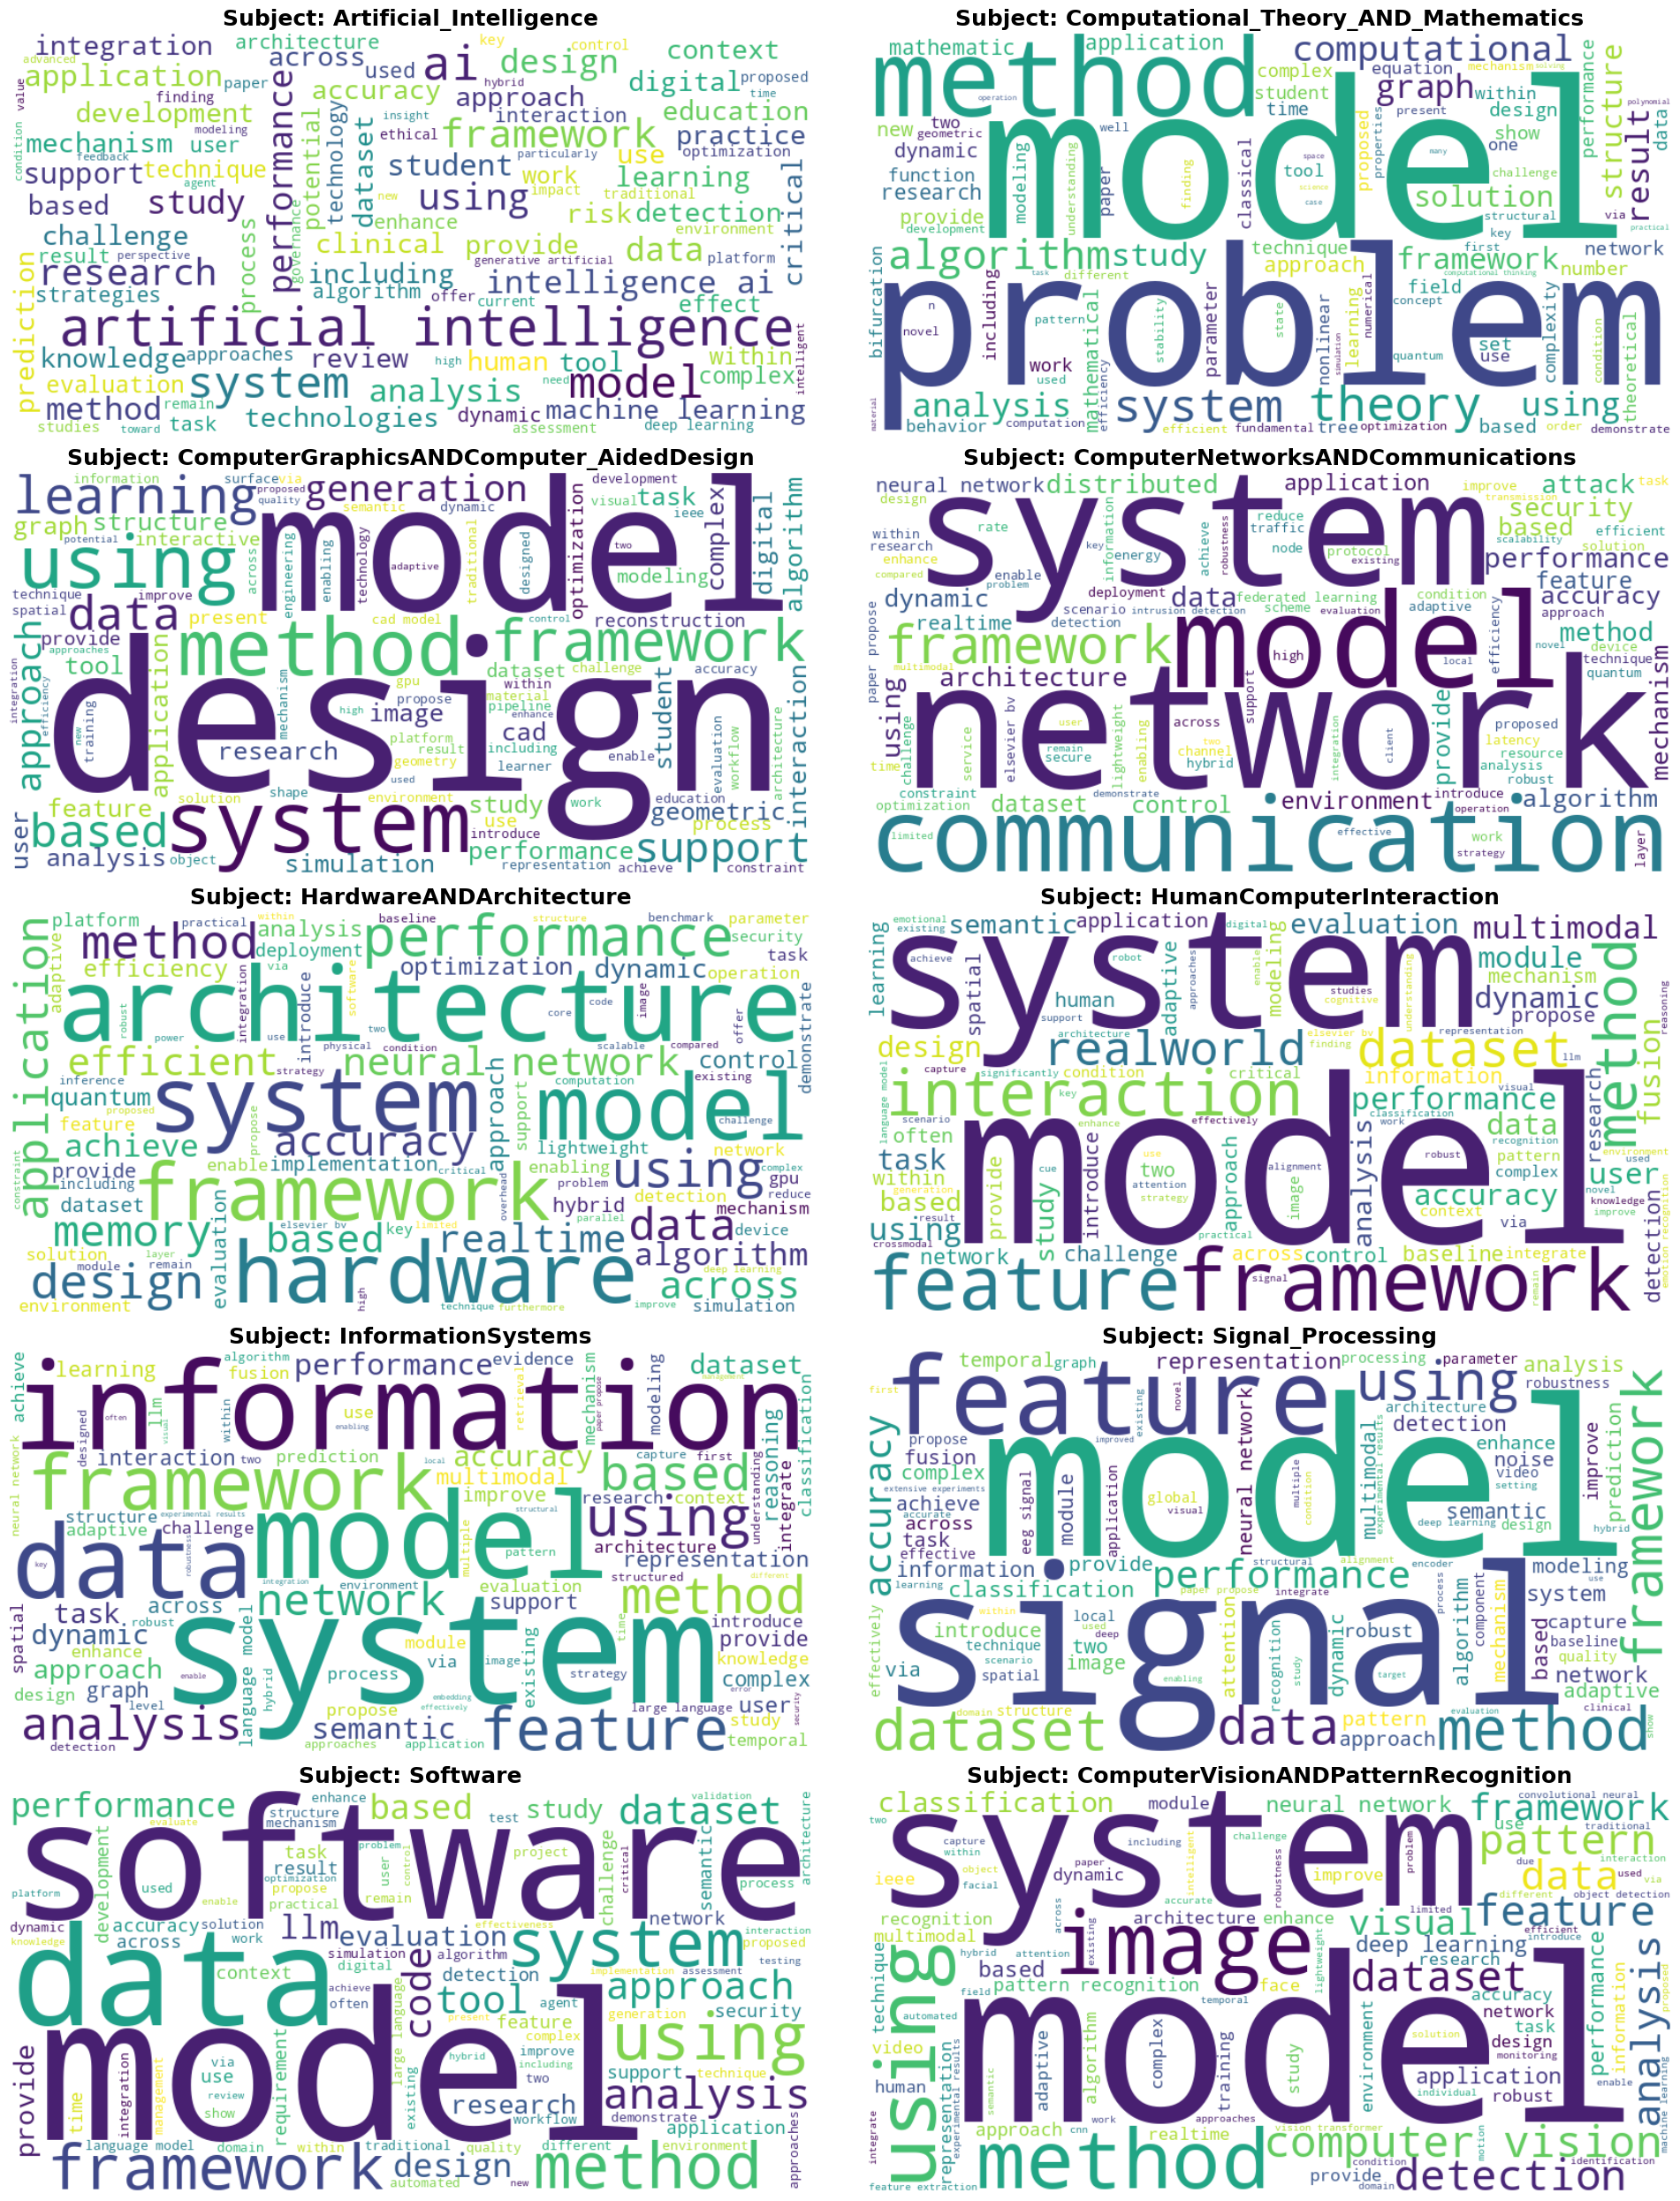

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

#หาชื่อสาขาวิชาทั้งหมดที่มีในชุดข้อมูล
subjects = df_clean['Subject'].unique()

#ตั้งค่าขนาดกราฟให้แสดง 5 แถว 2 คอลัมน์ (สำหรับ 10 สาขาวิชา)
fig, axes = plt.subplots(5, 2, figsize=(20, 25))
axes = axes.flatten()


for i, sub in enumerate(subjects):          #ดึงข้อึวามจาดคอลัมน์ Combined_Text เฉพาะสาขาวิชานั้น ๆ มารวมกันเป็นก้อนเดียว
  text_data = " ".join(df_clean[df_clean['Subject'] == sub]['Combined_Text'].tolist())

  #สร้าง Word Cloud
  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white',
      max_words=100,
      colormap='viridis',
      random_state=42
  ).generate(text_data)

    #วาดกราฟลงในตำแหน่ง (Subplot) ที่กำหนด
  axes[i].imshow(wordcloud, interpolation='bilinear')
  axes[i].set_title(f'Subject: {sub}', fontsize=18, fontweight='bold')
  axes[i].axis('off')

plt.tight_layout()   #ปรับระยะห่างระหว่างกราฟให้สวยงามและแสดงผล
plt.show()

# การสร้าง Visualization เป็นไฟล์ HTML

In [45]:
!pip install pyvis networkx

In [46]:
from networkx.algorithms.community import greedy_modularity_communities

print("กำลังสร้าง Network Graph และแบ่งกลุ่มสี...")
G = nx.Graph()

# 4.1 เพิ่มเส้นเชื่อม (Edges) ก่อน เพื่อให้ระบบวิเคราะห์ความสัมพันธ์ได้
for (kw1, kw2), weight in edge_counts.items():
    if weight > 1: # กรองเฉพาะคู่ที่เจอบ่อยกว่า 1 ครั้ง
        G.add_edge(kw1, kw2, value=weight, title=f"Co-occurred {weight} times")

# 4.2 ค้นหากลุ่มของคำศัพท์ (Community Detection)
# คำไหนเชื่อมโยงกันบ่อยจะถูกจัดให้อยู่กลุ่ม (สี) เดียวกัน
communities = list(greedy_modularity_communities(G))

# สร้าง Dictionary เก็บข้อมูลว่าคำศัพท์ไหนอยู่กลุ่มหมายเลขอะไร
node_groups = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_groups[node] = i

# 4.3 เพิ่มจุด (Nodes) เข้าไปในกราฟ พร้อมกำหนดขนาดและระบุ Group (PyVis จะแยกสีตาม Group)
for kw in G.nodes():
    kw_size = keyword_counts[kw]
    kw_group = node_groups.get(kw, 0)

    # อัปเดตข้อมูล Node ทีละตัว
    G.nodes[kw]['size'] = kw_size
    G.nodes[kw]['title'] = f"{kw} ({kw_size} papers) - Group {kw_group}"
    G.nodes[kw]['group'] = kw_group # นี่คือตัวแปรที่ทำให้สีต่างกัน

# 5. แปลงกราฟเป็นรูปแบบ Interactive ด้วย PyVis และบันทึกเป็น HTML
net = Network(height="700px", width="100%", bgcolor="#ffffff", font_color="black", notebook=True)
net.from_nx(G)

# เพิ่มเมนูปรับแต่งกราฟ
net.show_buttons(filter_=['physics'])

# กำหนด Path สำหรับเซฟไฟล์ลง Google Drive
html_file_path = '/content/drive/MyDrive/EDA_ScopusData_Midterm/keyword_co_occurrence.html'
net.save_graph(html_file_path)

print(f"บันทึกไฟล์ HTML Network Graph (แบบแยกสี) สำเร็จที่: {html_file_path}")

กำลังสร้าง Network Graph และแบ่งกลุ่มสี...
บันทึกไฟล์ HTML Network Graph (แบบแยกสี) สำเร็จที่: /content/drive/MyDrive/EDA_ScopusData_Midterm/keyword_co_occurrence.html


# คัดเลือกคอลัมน์ที่เหมาะสมกับการนำมาสร้าง feature **vector**

การเตรียมและแปลงข้อความในคอลัมน์ดังกล่าวให้เป็น Feature Vector ในรูปแบบเมทริกซ์ตัวเลข (Numerical Matrix) โดยใช้เทคนิค TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

#นำ Keywords มาต่อท้าย Combined_Text เพื่อเพิ่มบริบทที่เข้มข้นขึ้นให้กับโมเดล
df_clean['Final_Text'] = df_clean['Combined_Text'] + " " + df_clean['Author Keywords'] + " " + df_clean['Index Keywords']

#กำหนดคอลัมน์สำหรับ Features (X) และTarget (y)
X_raw = df_clean['Final_Text']
y_raw = df_clean['Subject']

#แปลงตัวแปรตาม(y) ให้เป็นหมวดหมู่ตัวเลข 0-9
print("กำลังแปลง Target Variable...")
encoder = LabelEncoder()
y = encoder.fit_transform(y_raw)

#แปลงข้อความ(X) ให้เป็น Feature Vector (เมทริกซ์ตัวเลข)
print("กำลังสร้าง Feature Vector ด้วย TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,    # เลือกคำศัพท์ที่มีความสำคัญและพบบ่อยที่สุด 5,000 คำ (ลดขนาดมิติข้อมูลป้องกันเครื่องค้าง)
    ngram_range=(1, 2)    # ให้โมเดลเรียนรู้ทั้งคำเดี่ยว (เช่น "machine") และคำคู่ที่มักมาด้วยกัน (เช่น "machine learning")
)

X = tfidf_vectorizer.fit_transform(X_raw)

# ตรวจสอบผลลัพธ์
print("-" * 50)
print(f"ขนาดของ Feature Matrix (X): {X.shape[0]} ตัวอย่าง, {X.shape[1]} ฟีเจอร์ (คำศัพท์)")
print(f"ขนาดของ Target (y): {y.shape[0]} ตัวอย่าง")
print("รายชื่อคลาสที่ถูกแปลงเป็นตัวเลข:", encoder.classes_)

กำลังแปลง Target Variable...
กำลังสร้าง Feature Vector ด้วย TF-IDF...
--------------------------------------------------
ขนาดของ Feature Matrix (X): 5036 ตัวอย่าง, 5000 ฟีเจอร์ (คำศัพท์)
ขนาดของ Target (y): 5036 ตัวอย่าง
รายชื่อคลาสที่ถูกแปลงเป็นตัวเลข: ['Artificial_Intelligence' 'Computational_Theory_AND_Mathematics'
 'ComputerGraphicsANDComputer_AidedDesign'
 'ComputerNetworksANDCommunications' 'ComputerVisionANDPatternRecognition'
 'HardwareANDArchitecture' 'HumanComputerInteraction' 'InformationSystems'
 'Signal_Processing' 'Software']
